# I extracted the shot data from sofascore

In [ ]:
from curl_cffi import requests
from bs4 import BeautifulSoup

url = "https://www.sofascore.com/api/v1/event/15697200/shotmap"

response = requests.get(url)
response.status_code
response.json()

print(response.status_code)
print(response.json())

data = response.json()
print(data.keys())

200
{'shotmap': [{'player': {'name': 'Tom Fellows', 'firstName': 'Tom Fellows', 'slug': 'tom-fellows', 'shortName': 'T. Fellows', 'position': 'M', 'jerseyNumber': '18', 'userCount': 405, 'gender': 'M', 'id': 1083026, 'fieldTranslations': {'nameTranslation': {'ar': 'توم فيلوز'}, 'shortNameTranslation': {'ar': 'ت. فيلوز'}}}, 'isHome': True, 'shotType': 'save', 'situation': 'assisted', 'playerCoordinates': {'x': 6.7, 'y': 69.7, 'z': 0}, 'bodyPart': 'right-foot', 'goalMouthLocation': 'high-right', 'goalMouthCoordinates': {'x': 0, 'y': 47.7, 'z': 32.3}, 'blockCoordinates': {'x': 1.1, 'y': 54, 'z': 0}, 'goalkeeper': {'name': 'Kepa Arrizabalaga', 'slug': 'kepa-arrizabalaga', 'shortName': 'K. Arrizabalaga', 'position': 'G', 'jerseyNumber': '13', 'userCount': 26476, 'gender': 'M', 'sofascoreId': 'KepaA', 'id': 232422, 'fieldTranslations': {'nameTranslation': {'ar': 'كيبا أريزابالاغا', 'bn': 'কেপা আরিজাবলাগা', 'hi': 'केपा अरिज़ाबलागा'}, 'shortNameTranslation': {'ar': 'ك. أريزابالاغا', 'bn': 'কে.

# I converted it into a DataFrame

In [ ]:
import pandas as pd

shots = pd.DataFrame(data["shotmap"])

print(shots.head())

                                              player  isHome shotType  \
0  {'name': 'Tom Fellows', 'firstName': 'Tom Fell...    True     save   
1  {'name': 'Riccardo Calafiori', 'slug': 'riccar...   False     miss   
2  {'name': 'Noni Madueke', 'slug': 'noni-madueke...   False     miss   
3  {'name': 'Gabriel Martinelli', 'slug': 'gabrie...   False     save   
4  {'name': 'Viktor Gyökeres', 'slug': 'viktor-gy...   False    block   

    situation               playerCoordinates    bodyPart goalMouthLocation  \
0    assisted   {'x': 6.7, 'y': 69.7, 'z': 0}  right-foot        high-right   
1   set-piece    {'x': 15.3, 'y': 53, 'z': 0}   left-foot              high   
2     regular  {'x': 11.7, 'y': 69.7, 'z': 0}   left-foot              high   
3  fast-break  {'x': 14.3, 'y': 33.2, 'z': 0}  right-foot        low-centre   
4   free-kick    {'x': 30, 'y': 49.3, 'z': 0}  right-foot        low-centre   

             goalMouthCoordinates              blockCoordinates  \
0  {'x': 0, 'y': 47

In [ ]:
import pandas as pd

shots_df = pd.DataFrame({
    "player": [s["player"]["name"] for s in data["shotmap"]],
    "team_home": [s["isHome"] for s in data["shotmap"]],
    "shot_type": [s["shotType"] for s in data["shotmap"]],
    "situation": [s["situation"] for s in data["shotmap"]],
    "body_part": [s["bodyPart"] for s in data["shotmap"]],
    "x": [s["playerCoordinates"]["x"] for s in data["shotmap"]],
    "y": [s["playerCoordinates"]["y"] for s in data["shotmap"]],
    "xg": [s.get("xg", 0) for s in data["shotmap"]],  # Use 0 if xG is missing
    "minute": [s["time"] for s in data["shotmap"]]
})

print(shots_df.head())

               player  team_home shot_type   situation   body_part     x  \
0         Tom Fellows       True      save    assisted  right-foot   6.7   
1  Riccardo Calafiori      False      miss   set-piece   left-foot  15.3   
2        Noni Madueke      False      miss     regular   left-foot  11.7   
3  Gabriel Martinelli      False      save  fast-break  right-foot  14.3   
4     Viktor Gyökeres      False     block   free-kick  right-foot  30.0   

      y  xg  minute  
0  69.7   0      90  
1  53.0   0      90  
2  69.7   0      90  
3  33.2   0      90  
4  49.3   0      90  


In [ ]:
shots_df.head()

,player,team_home,shot_type,situation,body_part,x,y,xg,minute
0,Tom Fellows,True,save,assisted,right-foot,6.7,69.7,0,90
1,Riccardo Calafiori,False,miss,set-piece,left-foot,15.3,53.0,0,90
2,Noni Madueke,False,miss,regular,left-foot,11.7,69.7,0,90
3,Gabriel Martinelli,False,save,fast-break,right-foot,14.3,33.2,0,90
4,Viktor Gyökeres,False,block,free-kick,right-foot,30.0,49.3,0,90


In [ ]:
shots_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31 entries, 0 to 30
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   player     31 non-null     object 
 1   team_home  31 non-null     bool   
 2   shot_type  31 non-null     object 
 3   situation  31 non-null     object 
 4   body_part  31 non-null     object 
 5   x          31 non-null     float64
 6   y          31 non-null     float64
 7   xg         31 non-null     int64  
 8   minute     31 non-null     int64  
dtypes: bool(1), float64(2), int64(2), object(4)
memory usage: 2.1+ KB


In [ ]:
shots_df.describe()

,x,y,xg,minute
count,31.000000,31.000000,31.0,31.000000
mean,14.893548,54.116129,0.0,48.064516
std,5.970591,12.090936,0.0,29.431203
min,3.600000,26.700000,0.0,6.000000
25%,11.300000,47.400000,0.0,24.500000
50%,14.300000,54.400000,0.0,45.000000
75%,18.600000,63.650000,0.0,75.500000
max,30.000000,70.900000,0.0,90.000000


# Basic Match Summary

# Total shots per team

In [ ]:
shots_df.groupby('team_home')['shot_type'].count()

,shot_type
team_home,
False,23
True,8


In [ ]:
shots_df.groupby(['team_home', 'shot_type']).size().unstack(fill_value=0)

shot_type,block,goal,miss,post,save
team_home,,,,,
False,10,1,6,0,6
True,1,2,2,1,2


# shots efficiency

In [ ]:
import pandas as pd

# Sample data
data = {
    'team_home': [False, True],
    'block': [10,1],
    'miss': [6, 2],
    'save': [6, 2],
    'goal': [1, 2],
    'post': [0,1]
}

df = pd.DataFrame(data)
df.set_index('team_home', inplace=True)

# Calculate total shots
df['total_shots'] = df.sum(axis=1)

# Calculate shots on target (saves)
df['shots_on_target'] = df['save']+ df['goal']

# Shooting accuracy %
df['shooting_accuracy'] = (df['shots_on_target'] / df['total_shots'] * 100).round(2)

print(df[['total_shots', 'shots_on_target', 'shooting_accuracy']])

           total_shots  shots_on_target  shooting_accuracy
team_home                                                 
False               23                7              30.43
True                 8                4              50.00


# Average Shot Distance

In [ ]:
shots_df.groupby('team_home')[['x','y']].mean()

,x,y
team_home,,
False,14.721739,54.021739
True,15.387500,54.387500


# Average distance to goal

In [ ]:
import numpy as np

# Assuming goal is at x=100, y=50
shots_df['distance_to_goal'] = np.sqrt((shots_df['x'])**2 + (shots_df['y'] - 50)**2)

shots_df.groupby('team_home')['distance_to_goal'].mean()

,distance_to_goal
team_home,
False,19.101289
True,20.773286


# Total shots per player

In [ ]:
shots_per_player = shots_df.groupby("player").size().reset_index(name="Total_Shots")
print(shots_per_player)

                player  Total_Shots
0   Christian Nørgaard            1
1            Finn Azaz            2
2        Gabriel Jesus            2
3    Gabriel Magalhães            1
4   Gabriel Martinelli            5
5          Kai Havertz            1
6          Leo Scienza            1
7      Martin Ødegaard            2
8           Max Dowman            7
9         Noni Madueke            1
10  Riccardo Calafiori            1
11        Ross Stewart            1
12        Shea Charles            1
13         Tom Fellows            3
14     Viktor Gyökeres            2


# Separate the teams

In [ ]:
home_shots = shots_df[shots_df["team_home"] == True]
away_shots = shots_df[shots_df["team_home"] == False]

# Number of situation per Team

In [ ]:
situation_counts= shots_df.groupby("team_home")["situation"].value_counts()
print(situation_counts)

team_home  situation 
False      assisted      11
           corner         7
           set-piece      2
           fast-break     1
           free-kick      1
           regular        1
True       assisted       3
           regular        3
           fast-break     2
Name: count, dtype: int64


# Number of situation by player

In [ ]:
situation_counts= shots_df.groupby("player")["situation"].value_counts()
print(situation_counts)

player              situation 
Christian Nørgaard  assisted      1
Finn Azaz           regular       2
Gabriel Jesus       corner        1
                    set-piece     1
Gabriel Magalhães   corner        1
Gabriel Martinelli  corner        3
                    assisted      1
                    fast-break    1
Kai Havertz         assisted      1
Leo Scienza         assisted      1
Martin Ødegaard     assisted      2
Max Dowman          assisted      5
                    corner        2
Noni Madueke        regular       1
Riccardo Calafiori  set-piece     1
Ross Stewart        fast-break    1
Shea Charles        assisted      1
Tom Fellows         assisted      1
                    fast-break    1
                    regular       1
Viktor Gyökeres     assisted      1
                    free-kick     1
Name: count, dtype: int64


# Shot outcome per player and position

In [28]:
shots_counts= shots_df.groupby(["team_home","player", "x","y"])["shot_type"].value_counts().reset_index(name="shots")
print(shots_counts)

    team_home              player     x     y shot_type  shots
0       False  Christian Nørgaard  18.7  64.4      save      1
1       False       Gabriel Jesus   6.4  52.3      miss      1
2       False       Gabriel Jesus  12.4  44.3      miss      1
3       False   Gabriel Magalhães  17.3  54.4     block      1
4       False  Gabriel Martinelli   3.6  34.6     block      1
5       False  Gabriel Martinelli   9.9  31.7     block      1
6       False  Gabriel Martinelli  14.3  33.2      save      1
7       False  Gabriel Martinelli  18.5  44.2      miss      1
8       False  Gabriel Martinelli  19.5  52.7     block      1
9       False         Kai Havertz  21.8  66.9     block      1
10      False     Martin Ødegaard  12.2  47.4      miss      1
11      False     Martin Ødegaard  22.2  66.7      save      1
12      False          Max Dowman   8.3  70.9      save      1
13      False          Max Dowman   8.9  57.6     block      1
14      False          Max Dowman  11.0  58.1     block

# Shot outcome per player and situation

In [18]:
shots_counts= shots_df.groupby(["team_home","player", "situation"])["shot_type"].value_counts().reset_index(name="shots")
print(shots_counts)

    team_home              player   situation shot_type  shots
0       False  Christian Nørgaard    assisted      save      1
1       False       Gabriel Jesus      corner      miss      1
2       False       Gabriel Jesus   set-piece      miss      1
3       False   Gabriel Magalhães      corner     block      1
4       False  Gabriel Martinelli    assisted     block      1
5       False  Gabriel Martinelli      corner     block      2
6       False  Gabriel Martinelli      corner      miss      1
7       False  Gabriel Martinelli  fast-break      save      1
8       False         Kai Havertz    assisted     block      1
9       False     Martin Ødegaard    assisted      miss      1
10      False     Martin Ødegaard    assisted      save      1
11      False          Max Dowman    assisted      save      3
12      False          Max Dowman    assisted     block      2
13      False          Max Dowman      corner     block      2
14      False        Noni Madueke     regular      miss

# Goals by body part

In [19]:
if 'count' not in shots_df.columns:
    shots_df['count'] = 1

In [20]:
df_goals = shots_df[shots_df['shot_type']=='goal'] \
    .groupby('body_part')['count'].sum().reset_index()

print(df_goals)

    body_part  count
0  right-foot      3


# Shots by body part

In [21]:
shots_df["body_part"].value_counts()

,count
body_part,
right-foot,15
left-foot,14
head,2


In [22]:
shot_type_counts = shots_df.groupby(["team_home"])["body_part"].value_counts()
print(shot_type_counts)

team_home  body_part 
False      left-foot     12
           right-foot     9
           head           2
True       right-foot     6
           left-foot      2
Name: count, dtype: int64


In [23]:
shot_type_counts = shots_df.groupby(["player","shot_type"])["body_part"].value_counts()
print(shot_type_counts)

player              shot_type  body_part 
Christian Nørgaard  save       right-foot    1
Finn Azaz           miss       left-foot     1
                    save       right-foot    1
Gabriel Jesus       miss       head          2
Gabriel Magalhães   block      left-foot     1
Gabriel Martinelli  block      right-foot    3
                    miss       right-foot    1
                    save       right-foot    1
Kai Havertz         block      left-foot     1
Leo Scienza         post       right-foot    1
Martin Ødegaard     miss       left-foot     1
                    save       left-foot     1
Max Dowman          block      left-foot     4
                    save       left-foot     2
                               right-foot    1
Noni Madueke        miss       left-foot     1
Riccardo Calafiori  miss       left-foot     1
Ross Stewart        goal       right-foot    1
Shea Charles        goal       right-foot    1
Tom Fellows         block      left-foot     1
                  

# Top players Performance Table

In [24]:
import pandas as pd
import numpy as np

# 1️⃣ Total shots per player
df_total_shots = shots_df.groupby('player').size().reset_index(name='total_shots')

# 2️⃣ Goals per player
df_goals = shots_df[shots_df['shot_type'] == 'goal'].groupby('player').size().reset_index(name='goals')

# 3️⃣ Shooting accuracy: shots on target = goal + save
df_on_target = shots_df[shots_df['shot_type'].isin(['goal','save'])].groupby('player').size().reset_index(name='on_target_shots')
df_accuracy = df_total_shots.merge(df_on_target, on='player', how='left')
df_accuracy['on_target_shots'] = df_accuracy['on_target_shots'].fillna(0)
df_accuracy['shooting_accuracy'] = (df_accuracy['on_target_shots'] / df_accuracy['total_shots'] * 100).round(2)

# 4️⃣ Average distance to goal per player
shots_df['distance_to_goal'] = np.sqrt(shots_df['x']**2 + (shots_df['y'] - 50)**2)
df_avg_distance = shots_df.groupby('player')['distance_to_goal'].mean().reset_index(name='avg_distance')

# 5️⃣ Merge everything together
df_top_players = df_total_shots.merge(df_goals, on='player', how='left') \
                                .merge(df_accuracy[['player','shooting_accuracy']], on='player', how='left') \
                                .merge(df_avg_distance, on='player', how='left')

# Fill NaN goals with 0
df_top_players['goals'] = df_top_players['goals'].fillna(0)

# Sort by goals first, then accuracy, then total shots
df_top_players = df_top_players.sort_values(
    by=['goals','shooting_accuracy','total_shots'],
    ascending=[False,False,False]
).reset_index(drop=True)

df_top_players

,player,total_shots,goals,shooting_accuracy,avg_distance
0,Ross Stewart,1,1.0,100.00,14.461673
1,Shea Charles,1,1.0,100.00,14.504137
2,Viktor Gyökeres,2,1.0,50.00,19.592111
3,Christian Nørgaard,1,0.0,100.00,23.601907
4,Finn Azaz,2,0.0,50.00,25.020250
5,Martin Ødegaard,2,0.0,50.00,20.127001
6,Max Dowman,7,0.0,42.86,19.163724
7,Tom Fellows,3,0.0,33.33,19.999149
8,Gabriel Martinelli,5,0.0,20.00,19.551462
9,Gabriel Jesus,2,0.0,0.00,10.224040


# Shooting accuracy per player

In [25]:
# Filter shots that are on target (goal or save)
df_on_target = shots_df[shots_df['shot_type'].isin(['goal','save'])] \
    .groupby('player').size().reset_index(name='on_target_shots')

# Total shots per player
df_total = shots_df.groupby('player').size().reset_index(name='total_shots')

# Merge to calculate shooting accuracy
df_accuracy = pd.merge(df_total, df_on_target, on='player', how='left')
df_accuracy['on_target_shots'] = df_accuracy['on_target_shots'].fillna(0)  # fill NaN for players with 0 on-target
df_accuracy['shooting_accuracy'] = (df_accuracy['on_target_shots'] / df_accuracy['total_shots'] * 100).round(2)

print(df_accuracy)

                player  total_shots  on_target_shots  shooting_accuracy
0   Christian Nørgaard            1              1.0             100.00
1            Finn Azaz            2              1.0              50.00
2        Gabriel Jesus            2              0.0               0.00
3    Gabriel Magalhães            1              0.0               0.00
4   Gabriel Martinelli            5              1.0              20.00
5          Kai Havertz            1              0.0               0.00
6          Leo Scienza            1              0.0               0.00
7      Martin Ødegaard            2              1.0              50.00
8           Max Dowman            7              3.0              42.86
9         Noni Madueke            1              0.0               0.00
10  Riccardo Calafiori            1              0.0               0.00
11        Ross Stewart            1              1.0             100.00
12        Shea Charles            1              1.0            

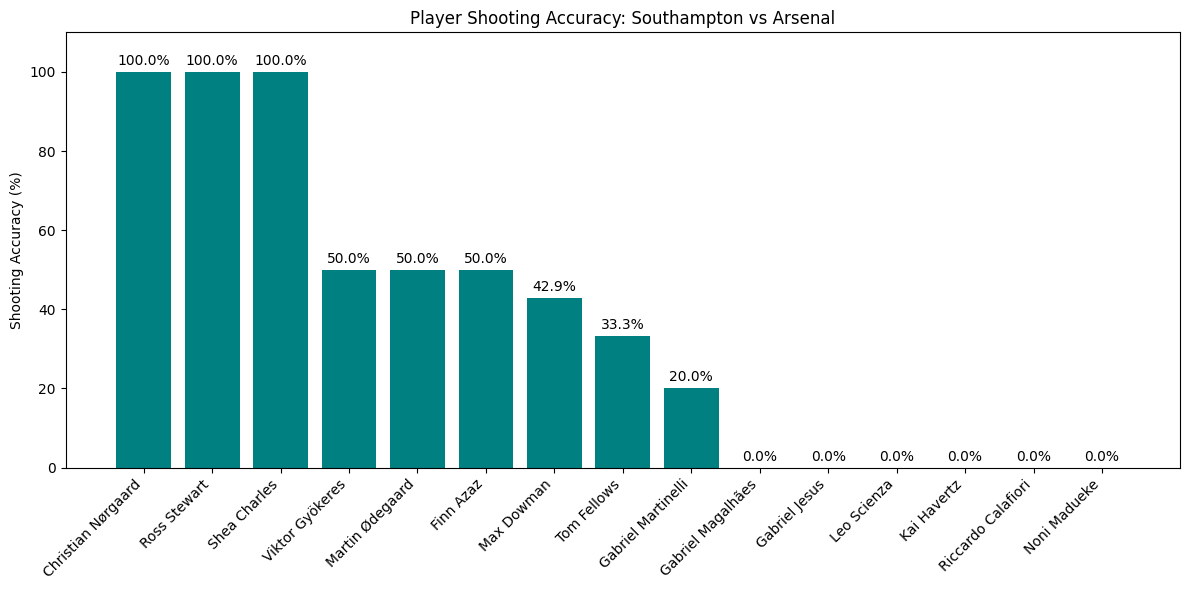

In [37]:
import matplotlib.pyplot as plt

# Sort by shooting accuracy
df_accuracy_sorted = df_accuracy.sort_values(by='shooting_accuracy', ascending=False)

plt.figure(figsize=(12,6))
bars = plt.bar(df_accuracy_sorted['player'], df_accuracy_sorted['shooting_accuracy'], color='teal')

# Labels
plt.ylabel("Shooting Accuracy (%)")
plt.title("Player Shooting Accuracy: Southampton vs Arsenal")
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 110)

# Show value on top of bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, f'{yval:.1f}%', ha='center', va='bottom')

plt.tight_layout()
plt.show()

# Shots Map

In [27]:
!pip install mplsoccer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.5/88.5 kB 1.9 MB/s eta 0:00:00


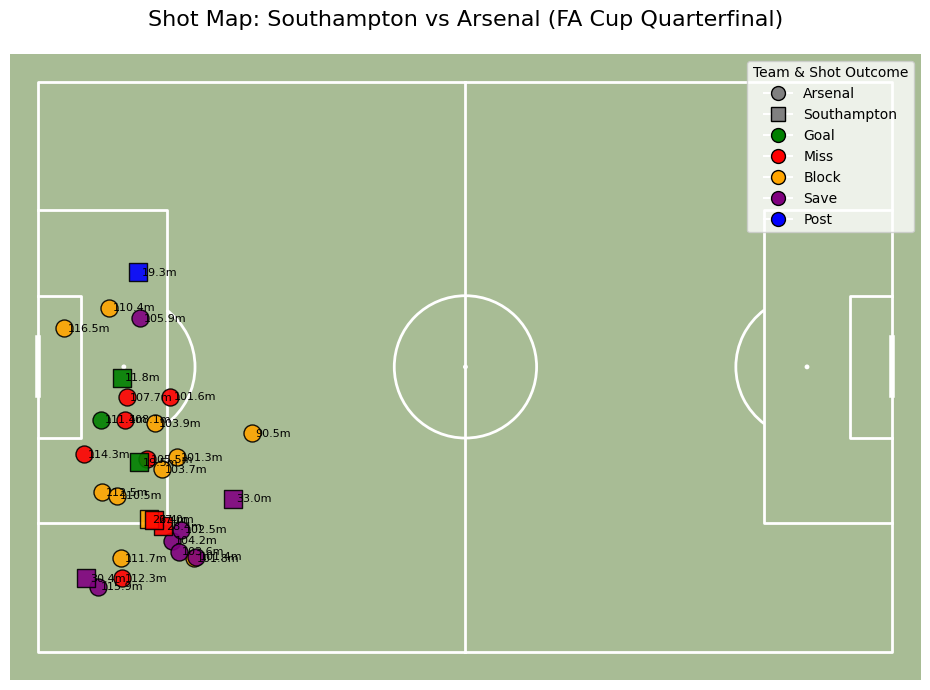

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mplsoccer import Pitch
from matplotlib.lines import Line2D

# Arsenal shots
arsenal_data = {
    "player": [
        "Christian Nørgaard","Gabriel Jesus","Gabriel Jesus","Gabriel Magalhães",
        "Gabriel Martinelli","Gabriel Martinelli","Gabriel Martinelli","Gabriel Martinelli",
        "Gabriel Martinelli","Kai Havertz","Martin Ødegaard","Martin Ødegaard",
        "Max Dowman","Max Dowman","Max Dowman","Max Dowman","Max Dowman","Max Dowman",
        "Max Dowman","Noni Madueke","Riccardo Calafiori","Viktor Gyökeres","Viktor Gyökeres"
    ],
    "x":[18.7,6.4,12.4,17.3,3.6,9.9,14.3,18.5,19.5,21.8,12.2,22.2,8.3,8.9,11.0,11.6,16.4,19.7,20.1,11.7,15.3,8.8,30.0],
    "y":[64.4,52.3,44.3,54.4,34.6,31.7,33.2,44.2,52.7,66.9,47.4,66.7,70.9,57.6,58.1,66.9,47.9,66.0,62.9,69.7,53.0,47.4,49.3],
    "shot_type":[
        "save","miss","miss","block","block","block","save","miss","block",
        "block","miss","save","save","block","block","block","block","save","save",
        "miss","miss","goal","block"
    ]
}

# Southampton shots
southampton_data = {
    "player": ["Finn Azaz","Finn Azaz","Leo Scienza","Ross Stewart","Shea Charles","Tom Fellows","Tom Fellows","Tom Fellows"],
    "x":[17.5,27.3,14.0,11.7,14.1,6.7,15.5,16.3],
    "y":[62.4,58.5,26.7,41.5,53.4,69.7,61.4,61.5],
    "shot_type":["miss","save","post","goal","goal","save","block","miss"]
}

df_arsenal = pd.DataFrame(arsenal_data)
df_soton = pd.DataFrame(southampton_data)

# Pitch
pitch = Pitch(pitch_type='statsbomb', pitch_color='#a8bc95', line_color='white')
fig, ax = pitch.draw(figsize=(12,7))

# Shot colors
shot_colors = {'goal':'green', 'miss':'red', 'block':'orange', 'save':'purple', 'post':'blue'}

# Distance to goal function (Arsenal attacks right, Southampton attacks left)
def distance_to_goal(x, y, home=True):
    if home:  # Arsenal attacks right
        return np.round(np.sqrt((120 - x)**2 + (40 - y)**2),1)
    else:     # Southampton attacks left
        return np.round(np.sqrt((0 - x)**2 + (40 - y)**2),1)

# Plot Arsenal shots
for idx, row in df_arsenal.iterrows():
    dist = distance_to_goal(row['x'], row['y'], home=True)
    ax.scatter(row['x'], row['y'], color=shot_colors.get(row['shot_type'],'black'),
               s=150, edgecolors='black', alpha=0.9, marker='o', zorder=5)
    ax.text(row['x']+0.5, row['y']+0.5, f"{dist}m", fontsize=8, color='black', zorder=6)

# Plot Southampton shots
for idx, row in df_soton.iterrows():
    dist = distance_to_goal(row['x'], row['y'], home=False)
    ax.scatter(row['x'], row['y'], color=shot_colors.get(row['shot_type'],'black'),
               s=150, edgecolors='black', alpha=0.9, marker='s', zorder=5)
    ax.text(row['x']+0.5, row['y']+0.5, f"{dist}m", fontsize=8, color='black', zorder=6)

# Legend
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Arsenal', markerfacecolor='grey', markersize=10, markeredgecolor='black'),
    Line2D([0], [0], marker='s', color='w', label='Southampton', markerfacecolor='grey', markersize=10, markeredgecolor='black')
]

shot_elements = [
    Line2D([0], [0], marker='o', color='w', label=k.capitalize(),
           markerfacecolor=v, markersize=10, markeredgecolor='black')
    for k,v in shot_colors.items()
]

ax.legend(handles=legend_elements + shot_elements, title='Team & Shot Outcome', loc='upper right')
ax.set_title("Shot Map: Southampton vs Arsenal (FA Cup Quarterfinal)", fontsize=16, pad=20)

plt.show()

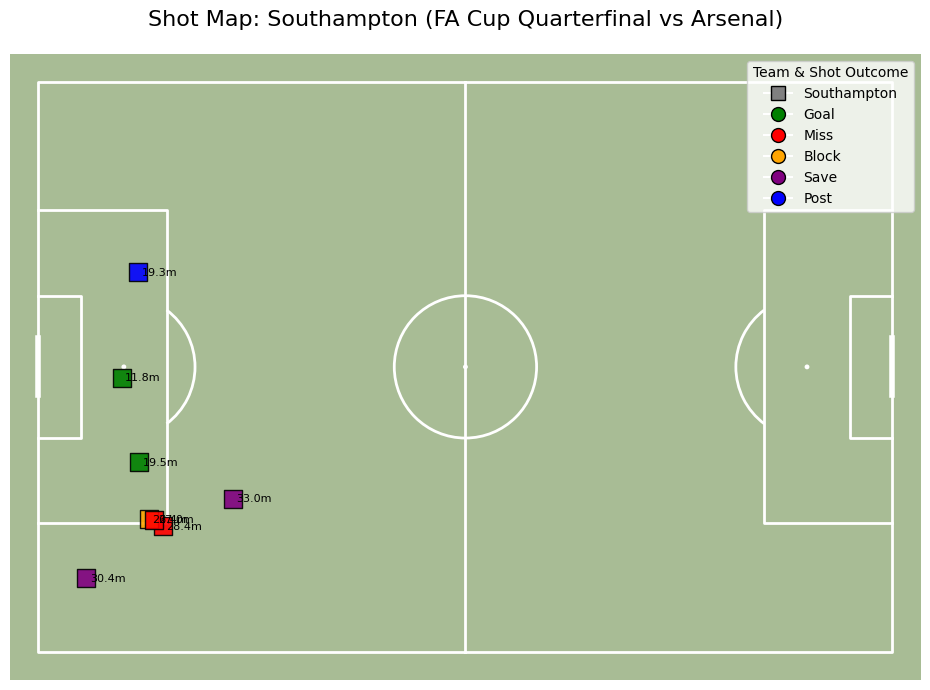

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mplsoccer import Pitch
from matplotlib.lines import Line2D

# Southampton shot data only
data_southampton = {
    "player": [
        "Finn Azaz", "Finn Azaz", "Leo Scienza", "Ross Stewart",
        "Shea Charles", "Tom Fellows", "Tom Fellows", "Tom Fellows"
    ],
    "x": [17.5, 27.3, 14.0, 11.7, 14.1, 6.7, 15.5, 16.3],
    "y": [62.4, 58.5, 26.7, 41.5, 53.4, 69.7, 61.4, 61.5],
    "shot_type": ["miss", "save", "post", "goal", "goal", "save", "block", "miss"],
    "shots": [1]*8
}

df_soton = pd.DataFrame(data_southampton)

# Create pitch
pitch = Pitch(pitch_type='statsbomb', pitch_color='#a8bc95', line_color='white')
fig, ax = pitch.draw(figsize=(12,7))

# Shot colors
shot_colors = {'goal':'green', 'miss':'red', 'block':'orange', 'save':'purple', 'post':'blue'}

# Function to calculate distance to goal
def distance_to_goal(x, y):
    return np.round(np.sqrt((0 - x)**2 + (40 - y)**2),1)  # Southampton attacks left

# Plot shots
for idx, row in df_soton.iterrows():
    dist = distance_to_goal(row['x'], row['y'])
    ax.scatter(
        row['x'], row['y'],
        color=shot_colors.get(row['shot_type'], 'black'),
        s=150,
        edgecolors='black',
        alpha=0.9,
        marker='s',  # Southampton = square
        zorder=5
    )
    ax.text(row['x']+0.5, row['y']+0.5, f"{dist}m", fontsize=8, color='black', zorder=6)

# Legend
shot_elements = [
    Line2D([0], [0], marker='s', color='w', label='Southampton', markerfacecolor='grey', markersize=10, markeredgecolor='black')
] + [
    Line2D([0], [0], marker='o', color='w', label=k.capitalize(),
           markerfacecolor=v, markersize=10, markeredgecolor='black')
    for k,v in shot_colors.items()
]

ax.legend(handles=shot_elements, title='Team & Shot Outcome', loc='upper right')
ax.set_title("Shot Map: Southampton (FA Cup Quarterfinal vs Arsenal)", fontsize=16, pad=20)

plt.show()

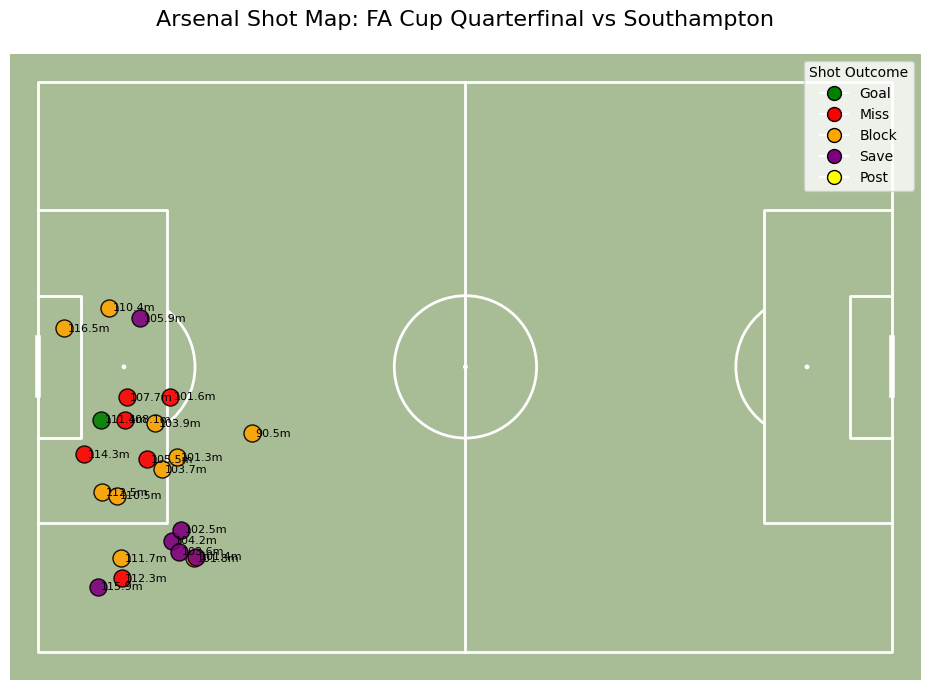

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mplsoccer import Pitch
from matplotlib.lines import Line2D

# Arsenal shots DataFrame
data = {
    "team_home": [False]*23,
    "player": [
        "Christian Nørgaard", "Gabriel Jesus", "Gabriel Jesus", "Gabriel Magalhães",
        "Gabriel Martinelli", "Gabriel Martinelli", "Gabriel Martinelli", "Gabriel Martinelli",
        "Gabriel Martinelli", "Kai Havertz", "Martin Ødegaard", "Martin Ødegaard",
        "Max Dowman", "Max Dowman", "Max Dowman", "Max Dowman", "Max Dowman", "Max Dowman",
        "Max Dowman", "Noni Madueke", "Riccardo Calafiori", "Viktor Gyökeres", "Viktor Gyökeres"
    ],
    "x": [
        18.7, 6.4, 12.4, 17.3, 3.6, 9.9, 14.3, 18.5, 19.5, 21.8,
        12.2, 22.2, 8.3, 8.9, 11.0, 11.6, 16.4, 19.7, 20.1, 11.7,
        15.3, 8.8, 30.0
    ],
    "y": [
        64.4, 52.3, 44.3, 54.4, 34.6, 31.7, 33.2, 44.2, 52.7, 66.9,
        47.4, 66.7, 70.9, 57.6, 58.1, 66.9, 47.9, 66.0, 62.9, 69.7,
        53.0, 47.4, 49.3
    ],
    "shot_type": [
        "save", "miss", "miss", "block", "block", "block", "save", "miss", "block",
        "block", "miss", "save", "save", "block", "block", "block", "block", "save",
        "save", "miss", "miss", "goal", "block"
    ],
    "shots": [1]*23
}

df = pd.DataFrame(data)

# Create pitch
pitch = Pitch(pitch_type='statsbomb', pitch_color='#a8bc95', line_color='white')
fig, ax = pitch.draw(figsize=(12,7))

# Shot colors
shot_colors = {'goal':'green', 'miss':'red', 'block':'orange', 'save':'purple', 'post':'yellow'}

# Function to calculate distance to goal (Arsenal attacking right)
def distance_to_goal(x, y):
    return np.round(np.sqrt((120 - x)**2 + (40 - y)**2),1)

# Plot Arsenal shots
for idx, row in df.iterrows():
    dist = distance_to_goal(row['x'], row['y'])
    ax.scatter(
        row['x'], row['y'],
        color=shot_colors.get(row['shot_type'], 'black'),
        s=150,
        edgecolors='black',
        alpha=0.9,
        marker='o',  # Arsenal: circle
        zorder=5
    )
    ax.text(row['x']+0.5, row['y']+0.5, f"{dist}m", fontsize=8, color='black', zorder=6)

# Legend
shot_elements = [
    Line2D([0], [0], marker='o', color='w', label=k.capitalize(),
           markerfacecolor=v, markersize=10, markeredgecolor='black')
    for k,v in shot_colors.items()
]

ax.legend(handles=shot_elements, title='Shot Outcome', loc='upper right')
ax.set_title("Arsenal Shot Map: FA Cup Quarterfinal vs Southampton", fontsize=16, pad=20)

plt.show()

# FA Cup Quarterfinal: Southampton vs Arsenal

Final Score: Southampton 2 – 1 Arsenal

# Objective

Analyze Arsenal’s attacking patterns, shot quality, finishing efficiency, and tactical trends to uncover insights that explain their performance and suggest improvements.

# Data Used
Shot data: Player, x/y location, shot type, body part used, situation (assisted, corner, set-piece, etc.)
Metrics: Total shots, shots on target, shooting accuracy, distance to goal, shot distribution
# Key Findings

Arsenal (team_home = False)

Total shots: 23
Shots on target: 7
Shooting accuracy: 30.43%
Average distance to goal: 19.1m
Shot types: Mostly assisted or from corners; few fast-break opportunities
Body part usage: Left foot – 12, Right foot – 9, Head – 2
Goal scorers: Viktor Gyökeres (1)
Top contributors:
Max Dowman: 7 shots, 3 on target
Gabriel Martinelli: 5 shots, 1 on target

# Observations:

Arsenal dominated possession and created numerous opportunities in central and left zones
Many shots were blocked (10) or saved (6), showing strong defensive resistance from Southampton
Shot conversion was low despite good xG opportunities from assisted and corner situations
Southampton (team_home = True)
Total shots: 8
Shots on target: 4
Shooting accuracy: 50%
Average distance to goal: 20.8m
Shot types: Mixed assisted, regular play, and fast-break opportunities
Body part usage: Right foot – 6, Left foot – 2
Goal scorers: Ross Stewart, Shea Charles (2 goals)

# Observations:

Southampton was clinical with fewer shots, converting 25% of total attempts into goals
Fast-break opportunities were effective, exploiting Arsenal’s defensive gaps
Shot Analysis
Arsenal’s attacking pattern: Predominantly assisted attacks and set-piece delivery; concentrated in central and left-flank zones
Southampton’s attacking pattern: Opportunistic and quick transitions; focused on fewer but higher quality chances
Shot distances: Arsenal: 15–25m range; Southampton: 17–21m range
# Tactical Implications
Arsenal created many chances but lacked finishing efficiency; predictable attacking zones made it easier for Southampton to block and save shots
Southampton’s compact defensive shape and counter-attacking strategy maximized goal conversion despite fewer shots
# Actionable Recommendations
Improve finishing: Train key attackers for clinical shots from central zones and tight spaces
Diversify attack: Introduce more right-flank penetration and secondary runs into scoring positions
Player development: Rotate or recruit attackers with high conversion rates under pressure
Set-piece optimization: Reevaluate corner and free-kick strategies to increase goal threat
# Takeaway

Arsenal dominated the game in terms of chance creation, but efficiency in front of goal was the deciding factor. Southampton’s clinical finishing and smart transitions underline the importance of converting opportunities, not just creating them.